# Dataset

### 1. Ultilities

In [4]:
import pandas as pd
import numpy as np
import re

def extract_top_features(code):
    """
    Extract features from the input code. There are 7 features:
        1. Blank line ratio: (blank lines) / (total lines)
        2. Whitespace ratio: (spaces + 4*tabs) / (total lines)
        3. Comment ratio: (number of comment lines) / (total lines)
        4. Paragraph's lines ratio: std(lines) / (std(lines) + mean(lines))
            with 'lines' is a list of number of lines in each paragraph.
        5. Paragraph' spaces ratio: std(spaces) / (std(spaces) + mean(spaces))
            with 'spaces' is a list of number of spaces in each paragraph.
        6. Paragraph - comment ratio: (comment lines) / (comment lines + paragraphs)
        7. Standard comments: (comment with a space at the beginning) / (total comments)

    Parameters:
        code (str): The code to extract features.

    Returns:
        list of features (list[float]).
    """
    if not code or not code.strip():
        return [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

    # Feat 1: blank lines ratio
    lines = code.strip().split('\n')
    total_lines = len(lines)
    
    blank_lines = sum(1 for line in lines if not line.strip())
    blank_line_ratio = blank_lines / total_lines if total_lines > 0 else 0.0

    # Feat 2: whitespace ratio
    whitespaces = [l.count(' ') + 4 * l.count('\t') for l in lines]
    mean_whitespaces = np.mean(whitespaces) if len(whitespaces) > 0 else 0
    whitespace_ratio = np.std(whitespaces) / mean_whitespaces if mean_whitespaces > 0 else 0.0

    # Feat 3: comment ratio
    # Find '//' and '#'
    comment_lines = sum(1 for line in lines if re.search(r'(?://|#)', line))
    comment_ratio = comment_lines / total_lines if total_lines > 0 else 0.0

    # Feat 4: paragraph lines
    pr_lines = [len(pr.split('\n')) for pr in code.split("\n\n")]
    pr_lines_ratio = (np.std(pr_lines)) / (np.mean(pr_lines) + np.std(pr_lines)) if len(pr_lines) > 0 else 0.0

    # Feat 5: paragraph spaces
    paragraphs = [p for p in code.split('\n\n') if len(p) > 0]
    pr_spaces = [pr.count(' ') for pr in paragraphs]
    std_pr_spaces = np.std(pr_spaces) 
    pr_spaces_ratio = std_pr_spaces / (np.mean(pr_spaces) + std_pr_spaces) if std_pr_spaces > 0 else 0.0

    # Feat 6: paragraphs and comments
    pr_comment_ratio = comment_lines / (len(paragraphs) + comment_lines) if comment_lines > 0 else 0.0

    # Feat 7: Standard comment
    _RE_UNIVERSAL_MARKER = re.compile(r"(?:#|//|--|%)(.?)")
    comments = _RE_UNIVERSAL_MARKER.findall(code)
    if not comments:
        standard_comment_ratio = 0.0
    else:
        is_spaced = np.array([c.isspace() for c in comments])
        standard_comment_ratio = np.mean(is_spaced)

    return [
        round(blank_line_ratio, 4),
        round(whitespace_ratio, 4),
        round(comment_ratio, 4),
        round(pr_lines_ratio, 4),
        round(pr_spaces_ratio, 4),
        round(pr_comment_ratio, 4),
        round(standard_comment_ratio, 4)
    ]

def get_full_dataset(file_path: str, return_labels=True):
    """
    Read data file, extract features from data, and return features (and labels).

    Parameters:
        file_path (str): Path to parquet file
        return_labels (bool): Whether to return labels

    Returns:
        feats (np.ndarray): shape (N, num_features)
        labels (np.ndarray): shape (N,) if return_labels=True
    """
    columns = ["code", "label"] if return_labels else ["code"]
    df = pd.read_parquet(file_path, columns=columns)
    codes = df["code"].tolist()
    feats = np.array([extract_top_features(c) for c in codes])

    if (return_labels is False):
        return feats

    labels = df["label"].to_numpy()
    return feats, labels

def get_full_dataset_from_file(file_path: str):
    """
    Read features and labels from parquet file.

    Parameters:
        file_path (str): The path to parquet file.

    Returns:
        feats (np.ndarray): shape (N, num_features)
        labels (np.ndarray): shape (N,)
    """
    data = pd.read_parquet(file_path).to_numpy()
    return data[:, :-1], data[:, -1]

### 2. Extract features (if not extracted yet)

In [ ]:
# Extract features
train_feats, train_labels = get_full_dataset('../data/train.parquet')
valid_feats, valid_labels = get_full_dataset('../data/validation.parquet')
test_sample_feats, test_sample_labels = get_full_dataset('../data/test_sample.parquet')
test_feats, test_labels = get_full_dataset('../data/test.parquet', return_labels=False)

# Save extracted features to file
cols = ['blank_line','whitespace','comment', 'paragraph_lines', 'pr_spaces_ratio', 'comment_pr_ratio', 'standard_comment', 'label']

df = pd.DataFrame(np.hstack([train_feats, train_labels.reshape(-1, 1)]), columns=cols)
df.to_parquet('../extracted_features/train.parquet')

df = pd.DataFrame(np.hstack([valid_feats, valid_labels.reshape(-1, 1)]), columns=cols)
df.to_parquet('../extracted_features/validation.parquet')

df = pd.DataFrame(np.hstack([test_sample_feats, test_sample_labels.reshape(-1, 1)]), columns=cols)
df.to_parquet('../extracted_features/test_sample.parquet')

df = pd.DataFrame(np.hstack([test_feats, test_labels.reshape(-1, 1)]), columns=cols[:-1])
df.to_parquet('../extracted_features/test.parquet')

### 3. Read extracted features from files

In [5]:
train_feats, train_labels = get_full_dataset_from_file('../extracted_features/train.parquet')
valid_feats, valid_labels = get_full_dataset_from_file('../extracted_features/validation.parquet')
test_sample_feats, test_sample_labels = get_full_dataset_from_file('../extracted_features/test_sample.parquet')
test_feats = pd.read_parquet('../extracted_features/test.parquet').to_numpy()

# Model

### A. Built-in models

In [ ]:
!python -m pip install xgboost catboost lightgbm numpy

####  1. Model configuration

In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier, NearestCentroid

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb

from sklearn.metrics import accuracy_score, f1_score

# List of models
random_forest_model = RandomForestClassifier(n_estimators=100, max_features=4)

logistic_regression_model = LogisticRegression()

knn_model = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)

nc_model = NearestCentroid()

xgboost_model = XGBClassifier(
    n_estimators=1000, 
    max_depth=5, 
    learning_rate=0.15, 
    eval_metric='logloss',
    scale_pos_weight=0.33 
)

catboost_model = CatBoostClassifier(
    iterations=1500,       
    learning_rate=0.01,
    depth=7,
    verbose=0
)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000, # 1000
    learning_rate=0.01,
    num_leaves=15,        # Important, 15
    random_state=42,
    verbosity=-1,
    scale_pos_weight=0.33,   # 0.3
)

#### 2. Training

In [235]:
_model = logistic_regression_model # Choose a model to use
feats = [0, 1, 2, 3, 4, 5, 6] # Choosing features for training,
num_train_samples = 200000 # Choose number of training samples, in range (0, 500000]

_model.fit(train_feats[:num_train_samples, feats], train_labels[:num_train_samples])

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### 3. Predict on test_sample and find the best threshold

In [158]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(labels, preds):
    """
    Draw confusion matrix of the predictions and the true labels.

    Arguments:
        labels (np.ndarray): list of true labels.
        preds (np.ndarray): list of model predictions.
    """
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Human', 'AI'], 
                yticklabels=['Human', 'AI'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def find_best_threshold(y_probs: np.ndarray, labels: np.ndarray):
    """
    Find the best threshold for AI probability, which gives the highest F1-macro score.A

    Arguments:
        y_probs (np.darray): Shape (N, 2), model predicted probabilities.
        labels (np.darray): Shape (N), correct labels.
    
    Returns:
        (float): The best threshold.
    """
    # Apply different thresholds to the AI prob
    thresholds = np.linspace(0, 1, 100)
    f1_macro_scores = [f1_score(labels, y_probs[:, 1] >= t, average='macro') for t in thresholds]

    # Draw diagram
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f1_macro_scores, color='blue', lw=2)
    best_t = thresholds[np.argmax(f1_macro_scores)]
    plt.axvline(best_t, color='red', linestyle='--', label=f'Best Threshold: {best_t:.2f}')
    plt.title(f'F1-macro vs Threshold (Max: {max(f1_macro_scores):.4f})')
    plt.xlabel('Threshold (AI)'); plt.ylabel('F1-macro'); plt.legend(); plt.show()

    return best_t

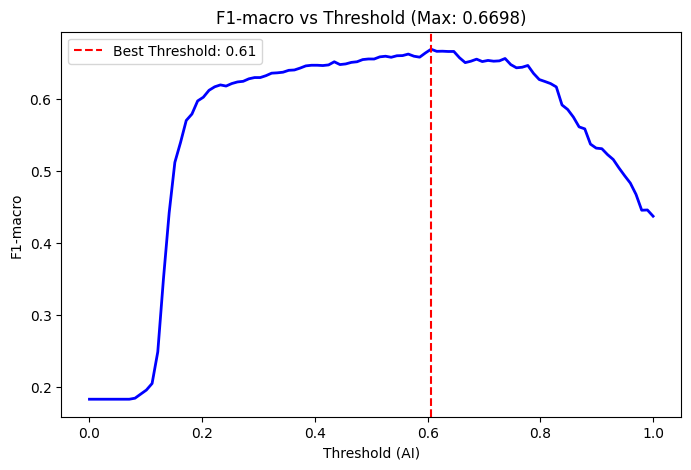

Accuracy: 71.60%
F1-score: 0.6698150499230344


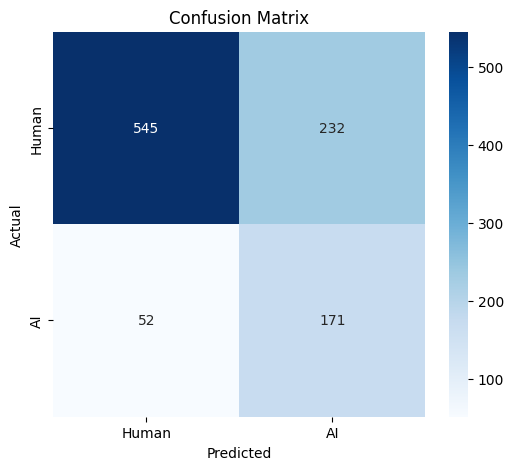

In [236]:
# Output probabilities
y_probs = _model.predict_proba(test_sample_feats[:, feats])
best_t = find_best_threshold(y_probs, test_sample_labels)

# Predictions based on the selected threshold
y_pred = y_probs[:, 1] > best_t
print(f"Accuracy: {accuracy_score(test_sample_labels, y_pred) * 100:.2f}%")
print(f"F1-score: {f1_score(test_sample_labels, y_pred, average='macro')}")
plot_confusion_matrix(test_sample_labels, y_pred)

#### 4. Predict on real test and save Submission file

In [237]:
import pandas as pd

test_predictions = _model.predict(test_feats[:, feats]).astype(int)
test_probs = _model.predict_proba(test_feats[:, feats])[:, 1]
test_predictions = test_probs >= best_t

ids = pd.read_parquet('../data/test.parquet', columns=["ID"])["ID"].values
df = pd.DataFrame({
    "ID": ids,   
    "label": test_predictions
})

df.to_csv("submission.csv", index=False)

### B. Custom MLP

#### 1. Model configuration

In [238]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, num_feats=1):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(num_feats, 16),
            nn.GELU(),
            nn.Linear(16, 8),
            nn.GELU(),
            nn.Linear(8, 4),
            nn.GELU(),
            nn.Linear(4, 2)
        )
    def forward(self, X):
        return self.fc(X)

#### 2. Train

In [239]:
def train_model(model, train_dataset: torch.tensor, valid_dataset: torch.tensor, num_feats = 3, batch_size=512, epochs=5, lr=1e-4, device="cpu"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    train_data_size, valid_data_size = len(train_dataset), len(valid_dataset)
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct = 0
        
        for i in range(0, train_data_size, batch_size):
            batch = train_dataset[i:i+batch_size]
            X, y = batch[:, :-1], batch[:, -1]
            X, y = X.to(device), y.to(device).long()

            optimizer.zero_grad()
            logits = model(X)

            # Backprop
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X.size(0)

            # Check predictions
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()

        train_loss /= train_data_size
        train_acc = correct / train_data_size

        # -- Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        
        with torch.no_grad():
            for i in range(0, valid_data_size, batch_size):
                batch = valid_dataset[i:i+batch_size]
                X, y = batch[:, :-1], batch[:, -1]
                X, y = X.to(device), y.to(device).long()

                # Valid loss
                logits = model(X)
                loss = criterion(logits, y)
                val_loss += loss.item() * X.size(0)

                # Valid accuracy
                preds = torch.argmax(logits, dim=1)
                correct += (preds == y).sum().item()
            
            val_loss /= valid_data_size
            val_acc = correct / valid_data_size

            print(f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

In [256]:
feats = [0, 1, 2, 3, 4, 5, 6] # Choose features for training
model = MLP(num_feats=len(feats)) # <-- Comment here for resuming training

_train_dataset = torch.tensor(np.hstack([train_feats[:500000, feats], train_labels[:500000].reshape(-1, 1)]), dtype=torch.float32)
_valid_dataset = torch.tensor(np.hstack([test_sample_feats[:1000, feats], test_sample_labels[:1000].reshape(-1, 1)]), dtype=torch.float32)

train_model(model, _train_dataset, _valid_dataset, device="cuda", lr=1e-4, epochs=5, batch_size=128)

Epoch 1/5 | Train Loss: 0.5671 Acc: 0.6906 | Val Loss: 0.6179 Acc: 0.6880
Epoch 2/5 | Train Loss: 0.4834 Acc: 0.7658 | Val Loss: 0.6341 Acc: 0.6920
Epoch 3/5 | Train Loss: 0.4604 Acc: 0.7899 | Val Loss: 0.6649 Acc: 0.7020
Epoch 4/5 | Train Loss: 0.4330 Acc: 0.8136 | Val Loss: 0.7231 Acc: 0.7030
Epoch 5/5 | Train Loss: 0.4202 Acc: 0.8210 | Val Loss: 0.7638 Acc: 0.6940


#### 3. Run tests

In [243]:
def testing_predict(model, test_dataset: torch.tensor, batch_size=64, return_probs=False):
    test_data_size = len(test_dataset)

    model.eval()
    device = "cuda"

    test_predictions = []
    with torch.no_grad():
        for i in range(0, test_data_size, batch_size):
            batch = test_dataset[i:i+batch_size]
            X = batch[:, :].to(device)

            logits = model(X)
            preds = torch.argmax(logits, dim=1) if return_probs is False else logits
            test_predictions.extend(preds.cpu().tolist())

    return np.array(test_predictions)

##### 3a. Test_sample and find best threshold

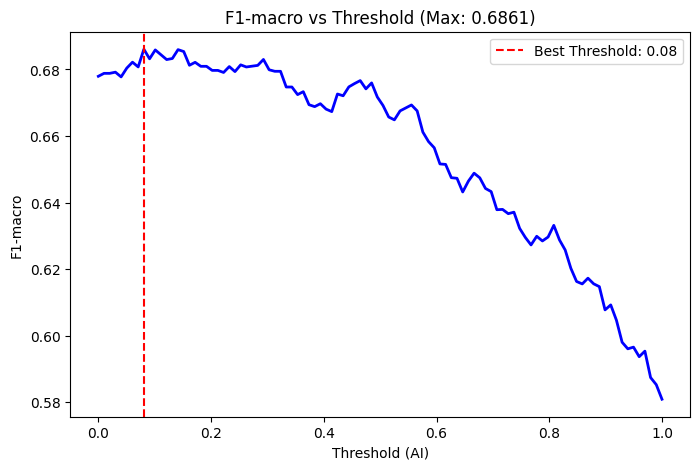

Accuracy:  0.73
F1 score:  0.6860917728141523


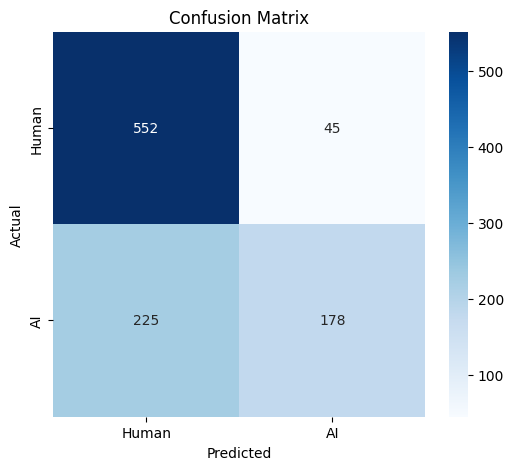

In [257]:
test_sample_feats_torch = torch.tensor(test_sample_feats[:, feats], dtype=torch.float32)
y_probs = testing_predict(model, test_sample_feats_torch, return_probs=True)

# Find the best threshold
best_t = find_best_threshold(y_probs, test_sample_labels)
test_predictions = y_probs[:, 1] > best_t

# Accuracy
correct = np.sum(test_sample_labels == test_predictions)
print("Accuracy: ", correct / len(test_sample_labels))

# F1-macro score
print("F1 score: ", f1_score(test_predictions, test_sample_labels, average='macro'))

# Confusion matrix
plot_confusion_matrix(test_predictions, test_sample_labels)

##### 3b. Real test + save submission

In [258]:
import pandas as pd

test_feats_torch = torch.tensor(test_feats[:], dtype=torch.float32)

test_probs = testing_predict(model, test_feats_torch[:, feats], return_probs=True)
test_predictions = test_probs[:, 1] > best_t

ids = pd.read_parquet('../data/test.parquet', columns=["ID"])["ID"].values
df = pd.DataFrame({
    "ID": ids,   
    "label": test_predictions
})

df.to_csv("submission.csv", index=False)